In [1]:
import sys
import os 

import numpy as np 
import pandas as pd 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

sys.path.append(os.path.abspath("../.."))
from src.results_manager import ResultsManager

rm = ResultsManager("random_forest")

In [2]:
from src.load_processed import load_processed_data

dataset = load_processed_data("../../data/processed/preprocessed.npz")

X_train = dataset["X_train"]
X_test = dataset["X_test"]

y_train = dataset["y_train"]
y_test = dataset["y_test"]

font_test = dataset["font_test"]
italic_test = dataset["italic_test"]
strength_test = dataset["strength_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Data type:", X_train.dtype)

Train shape: (666136, 400)
Test shape: (166534, 400)
Number of classes: 256
Data type: float32


In [3]:
model = RandomForestClassifier(
    n_estimators = 60,
    max_depth = 20,
    max_features = "sqrt",
    min_samples_split = 10,
    min_samples_leaf = 5,
    n_jobs = 3,
    random_state = 42,
    verbose = 2
)

In [4]:
import time 

print("Training model ... ")
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"Training done in {training_time:.2f} seconds")

trained_now = True

Training model ... 


[Parallel(n_jobs=3)]: Using backend ThreadingBackend with 3 concurrent workers.


building tree 1 of 60building tree 2 of 60
building tree 3 of 60

building tree 4 of 60
building tree 5 of 60
building tree 6 of 60
building tree 7 of 60
building tree 8 of 60
building tree 9 of 60
building tree 10 of 60
building tree 11 of 60
building tree 12 of 60
building tree 13 of 60
building tree 14 of 60
building tree 15 of 60
building tree 16 of 60
building tree 17 of 60
building tree 18 of 60
building tree 19 of 60
building tree 20 of 60
building tree 21 of 60
building tree 22 of 60
building tree 23 of 60
building tree 24 of 60
building tree 25 of 60
building tree 26 of 60
building tree 27 of 60
building tree 28 of 60
building tree 29 of 60
building tree 30 of 60
building tree 31 of 60
building tree 32 of 60
building tree 33 of 60
building tree 34 of 60
building tree 35 of 60
building tree 36 of 60
building tree 37 of 60
building tree 38 of 60
building tree 39 of 60


[Parallel(n_jobs=3)]: Done  35 tasks      | elapsed:  2.8min


building tree 40 of 60
building tree 41 of 60
building tree 42 of 60
building tree 43 of 60
building tree 44 of 60
building tree 45 of 60
building tree 46 of 60
building tree 47 of 60
building tree 48 of 60
building tree 49 of 60
building tree 50 of 60
building tree 51 of 60
building tree 52 of 60
building tree 53 of 60
building tree 54 of 60
building tree 55 of 60
building tree 56 of 60
building tree 57 of 60
building tree 58 of 60
building tree 59 of 60
building tree 60 of 60
Training done in 273.07 seconds


[Parallel(n_jobs=3)]: Done  60 out of  60 | elapsed:  4.5min finished


In [5]:

y_pred = model.predict(X_test)

[Parallel(n_jobs=3)]: Using backend ThreadingBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  35 tasks      | elapsed:    4.7s
[Parallel(n_jobs=3)]: Done  60 out of  60 | elapsed:    7.3s finished


In [6]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average = "macro")
weighted_f1 = f1_score(y_test, y_pred, average = "weighted")

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Accuracy: 0.7080956441327296
Macro F1: 0.6004198791567728
Weighted F1: 0.6977744474232971


In [7]:
import json 

if training_time is None:
    training_time = -0.1

results = {
    "model": "random_forest",
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "training_time_seconds": float(training_time)
}

# save results in .json file only if model is trained now: 
if trained_now:
    rm.save_metrics(results)


Metrics saved to ../../results/random_forest/metrics.json


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(f"Shape: {cm.shape}\n")
print(cm)

Shape: (256, 256)

[[121   5   5 ...   0   0   1]
 [  4 200  21 ...   0   0   0]
 [  0  10 439 ...   0   0   0]
 ...
 [  0   0   0 ... 218   0   0]
 [  0   2   1 ...   0 219  10]
 [  1   0   0 ...   0   7  92]]


In [9]:
errors = []

n = cm.shape[0]

for true_class in range(n):
    for pred_class in range(n):
        if true_class != pred_class:            # avoid diag elements 
            count = cm[true_class, pred_class]
            errors.append((true_class, pred_class, count))

errors = sorted(errors, key = lambda x: x[2], reverse = True)

top_errors = errors[:10]

top_errors_readable = []
for true_class, pred_class, count in top_errors:
    label = f"{chr(true_class)} → {chr(pred_class)}"
    top_errors_readable.append((label, count))

errors_df = pd.DataFrame(
    top_errors_readable,
    columns = ["confusion", "count"]
)

rm.save_dataframe(errors_df, "top_confusions")

errors_df

Dataframe saved to ../../results/random_forest/top_confusions.csv


,confusion,count
0,O → 0,162
1,| → _,123
2,² → 2,120
3,³ → 3,116
4, → _,115
5,¹ → 1,114
6,¯ → _,110
7,→,103
8,o → 0,103
9,- → _,102


### Per-class accuracy 

In [10]:
# number of correct classifications per class (diag elements)
correct = np.diag(cm)

# total number of samples per class
total = cm.sum(axis = 1)

# per-class accuracy
per_class_accuracy = correct / total

# ASCII oznake klasa
labels = [f"{i}:{repr(chr(i))}" for i in range(cm.shape[0])]

# dataframe sa rezultatima
per_class_df = pd.DataFrame({
    "character": labels,
    "accuracy": per_class_accuracy,
    "correct": correct,
    "total": total,
    "percentage_%": per_class_accuracy *100
})

# sortiranje po tacnosti
per_class_df = per_class_df.sort_values("accuracy")
rm.save_dataframe(per_class_df, "class_accuracy")

worst_classified = per_class_df.head(10)
rm.save_dataframe(worst_classified, "worst_classified_classes")
print("Worst classified characters:")
print(worst_classified)

best_classified = per_class_df.tail(10)
rm.save_dataframe(best_classified, "best_classified_classes")
print("\nBest classified characters:")
print(best_classified)

Dataframe saved to ../../results/random_forest/class_accuracy.csv
Dataframe saved to ../../results/random_forest/worst_classified_classes.csv
Worst classified characters:
      character  accuracy  correct  total  percentage_%
159  159:'\x9f'  0.135135       25    185     13.513514
156  156:'\x9c'  0.139785       26    186     13.978495
157  157:'\x9d'  0.175824       32    182     17.582418
16    16:'\x10'  0.191919       76    396     19.191919
153  153:'\x99'  0.195876       38    194     19.587629
18    18:'\x12'  0.215385       84    390     21.538462
151  151:'\x97'  0.221649       43    194     22.164948
150  150:'\x96'  0.230769       45    195     23.076923
132  132:'\x84'  0.231884       64    276     23.188406
21    21:'\x15'  0.239741      111    463     23.974082
Dataframe saved to ../../results/random_forest/best_classified_classes.csv

Best classified characters:
   character  accuracy  correct  total  percentage_%
56    56:'8'  0.912349     3997   4381     91.234878
57 

In [11]:
import warnings
warnings.filterwarnings("ignore")

font_results = []

for font in np.unique(font_test):
    mask = font_test == font

    acc = accuracy_score(
        y_test[mask],
        y_pred[mask]
    )

    font_results.append({
        "font": font,
        "samples": mask.sum(),
        "accuracy": acc
    })


font_df = pd.DataFrame(font_results)
font_df = font_df.sort_values("accuracy", ascending = False)
font_df["accuracy_%"] = (font_df["accuracy"] * 100).round(2)
rm.save_dataframe(font_df, "font_accuracy")

font_df

Dataframe saved to ../../results/random_forest/font_accuracy.csv


,font,samples,accuracy,accuracy_%
100,NUMERICS,2780,0.997842,99.78
43,E13B,4718,0.997457,99.75
101,OCRA,13077,0.987000,98.70
102,OCRB,18706,0.984604,98.46
91,MONEY,1499,0.982655,98.27
...,...,...,...,...
58,GADUGI,855,0.237427,23.74
64,GOTHICE,272,0.235294,23.53
123,SCRIPT,438,0.214612,21.46
45,EDWARDIAN,178,0.207865,20.79


In [12]:
italic_results = []

for value in np.unique(italic_test):
    mask = italic_test == value 

    acc = accuracy_score(
        y_test[mask],
        y_pred[mask]
    )

    italic_results.append({
        "italic": value, 
        "samples": mask.sum(),
        "accuracy": acc
    })

italic_df = pd.DataFrame(italic_results)
italic_df["accuracy_%"] = (italic_df["accuracy"] * 100).round(2)
rm.save_dataframe(italic_df, "italic_accuracy")

italic_df

Dataframe saved to ../../results/random_forest/italic_accuracy.csv


,italic,samples,accuracy,accuracy_%
0,0,116206,0.783428,78.34
1,1,50328,0.534156,53.42


57.13% karaktera koji nisu italic je klasifikovano tacno  
26.15% karaktera koji jesu italic je klasifikovano tacno

In [13]:
bins = np.linspace(0, 1, 6)   # 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

strength_results = []

for i in range(len(bins)-1):

    mask = (strength_test >= bins[i]) & (strength_test < bins[i+1])

    samples = mask.sum()
    if samples == 0:
        acc = np.nan
    else: 
        acc = accuracy_score(
            y_test[mask],
            y_pred[mask]
        )


    strength_results.append({
        "strength_range": labels[i],
        "samples": samples,
        "accuracy": acc
    })


strength_df = pd.DataFrame(strength_results)
strength_df["accuracy_%"] = (strength_df["accuracy"] * 100).round(2)

rm.save_dataframe(strength_df, "strength_accuracy")

strength_df

Dataframe saved to ../../results/random_forest/strength_accuracy.csv


,strength_range,samples,accuracy,accuracy_%
0,0.0-0.2,0,NaN,NaN
1,0.2-0.4,0,NaN,NaN
2,0.4-0.6,114924,0.780089,78.01
3,0.6-0.8,51610,0.547781,54.78
4,0.8-1.0,0,NaN,NaN


Deblji karakteri imaju više spojenih piksela, pa se oblici slova međusobno približavaju.  
Na primer: 8 vs B, 5 vs S, O vs 0 -> jos slicniji kada je font deblji

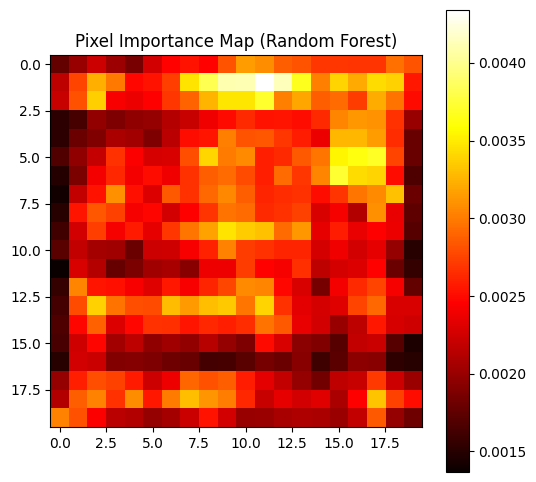

In [14]:
from matplotlib import pyplot as plt

importances = model.feature_importances_
importance_map = importances.reshape(20,20)

plt.figure(figsize=(6,6))
plt.imshow(importance_map, cmap="hot")
plt.colorbar()
plt.title("Pixel Importance Map (Random Forest)")
plt.show()